# House Price Prediction

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# 1. Define the Problem
## Problem Definition
The objective of this project is to build a machine learning model that can accurately predict the price of a house based on its various features.
This is a regression problem, where the goal is to predict a continuous target variable the house price.
### Input (Features)

Numerical Features:

1. area
2. bedrooms
3. bathrooms
4. stories
5. parking

Binary / Categorical Features:

1. mainroad
2. guestroom
3. basement
4. hotwaterheating
5. airconditioning
6. prefarea
7. furnishingstatusunfurnished

### Output (Target Variable)

price: The price of the house (continuous value, typically in local currency units)



# 2. Data Acquisition
### Data Source
The dataset used in this project is a publicly available house price dataset, commonly used for regression tasks.
How the Data Was Acquired:

### How Data Was Acquired
1. Downloaded the dataset from **Kaggle**.
2. Uploaded the CSV file to Google Colab.
3. Loaded the data using pandas:
   

# 3. Load Dataset

In [59]:
# Data Loading

df = pd.read_csv('Housing.csv')

print("Dataset loaded successfully!")

print("\n" + "="*50)
print("HOUSE PRICE PREDICTION DATASET OVERVIEW")
print("="*50)

print(f"Dataset Shape: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"Number of Features: {df.shape[1] - 1}")   # Excluding target
print(f"Target Variable : price")



Dataset loaded successfully!

HOUSE PRICE PREDICTION DATASET OVERVIEW
Dataset Shape: 545 rows × 13 columns
Number of Features: 12
Target Variable : price


## 4. Exploratory Data Analysis (EDA)


In [60]:
df.columns

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='object')

In [ ]:

print(df.head())

      price  area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0  13300000  7420         4          2        3      yes        no       no   
1  12250000  8960         4          4        4      yes        no       no   
2  12250000  9960         3          2        2      yes        no      yes   
3  12215000  7500         4          2        2      yes        no      yes   
4  11410000  7420         4          1        2      yes       yes      yes   

  hotwaterheating airconditioning  parking prefarea furnishingstatus  
0              no             yes        2      yes        furnished  
1              no             yes        3       no        furnished  
2              no              no        2      yes   semi-furnished  
3              no             yes        3      yes        furnished  
4              no             yes        2       no        furnished  


In [ ]:
df.tail()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
540,1820000,3000,2,1,1,yes,no,yes,no,no,2,no,unfurnished
541,1767150,2400,3,1,1,no,no,no,no,no,0,no,semi-furnished
542,1750000,3620,2,1,1,yes,no,no,no,no,0,no,unfurnished
543,1750000,2910,3,1,1,no,no,no,no,no,0,no,furnished
544,1750000,3850,3,1,2,yes,no,no,no,no,0,no,unfurnished


In [ ]:
print(df.isnull().sum())

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64


In [4]:
df.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
540,False
541,False
542,False
543,False


In [5]:
df.drop_duplicates(inplace=True)


In [6]:
print(df.describe())

              price          area    bedrooms   bathrooms     stories  \
count  5.450000e+02    545.000000  545.000000  545.000000  545.000000   
mean   4.766729e+06   5150.541284    2.965138    1.286239    1.805505   
std    1.870440e+06   2170.141023    0.738064    0.502470    0.867492   
min    1.750000e+06   1650.000000    1.000000    1.000000    1.000000   
25%    3.430000e+06   3600.000000    2.000000    1.000000    1.000000   
50%    4.340000e+06   4600.000000    3.000000    1.000000    2.000000   
75%    5.740000e+06   6360.000000    3.000000    2.000000    2.000000   
max    1.330000e+07  16200.000000    6.000000    4.000000    4.000000   

          parking  
count  545.000000  
mean     0.693578  
std      0.861586  
min      0.000000  
25%      0.000000  
50%      0.000000  
75%      1.000000  
max      3.000000  


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


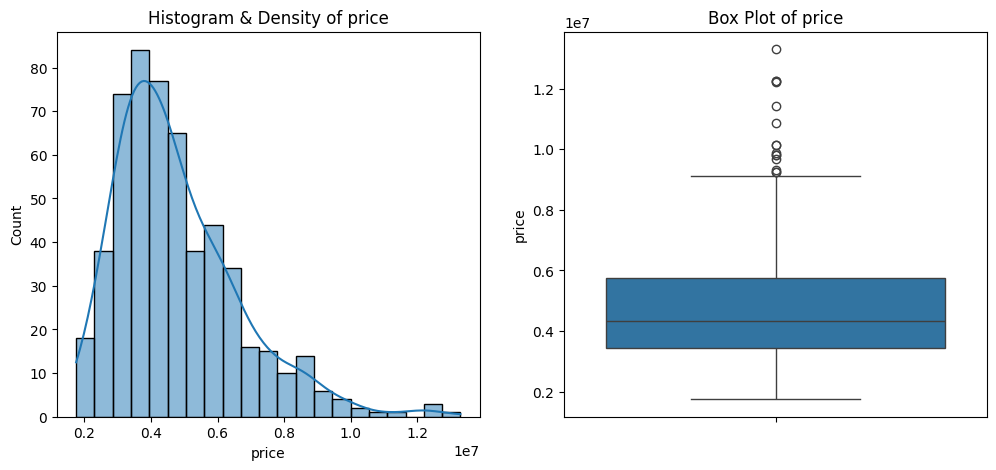

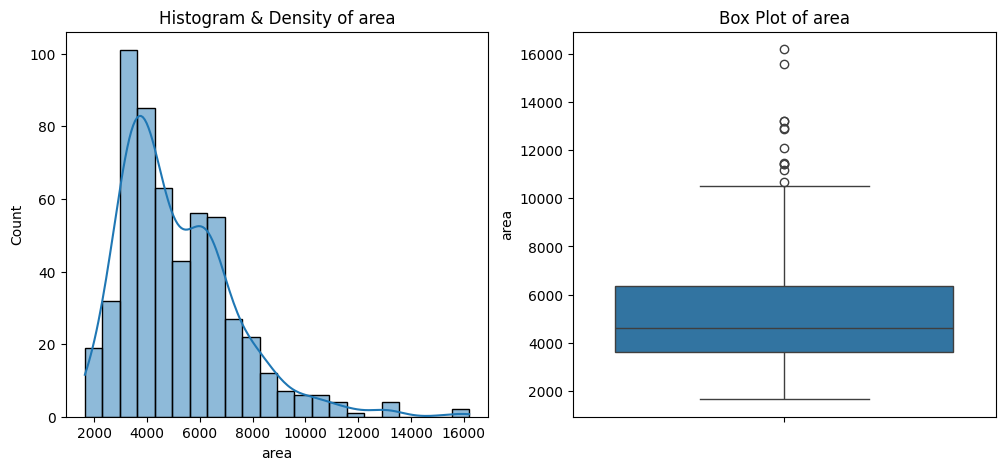

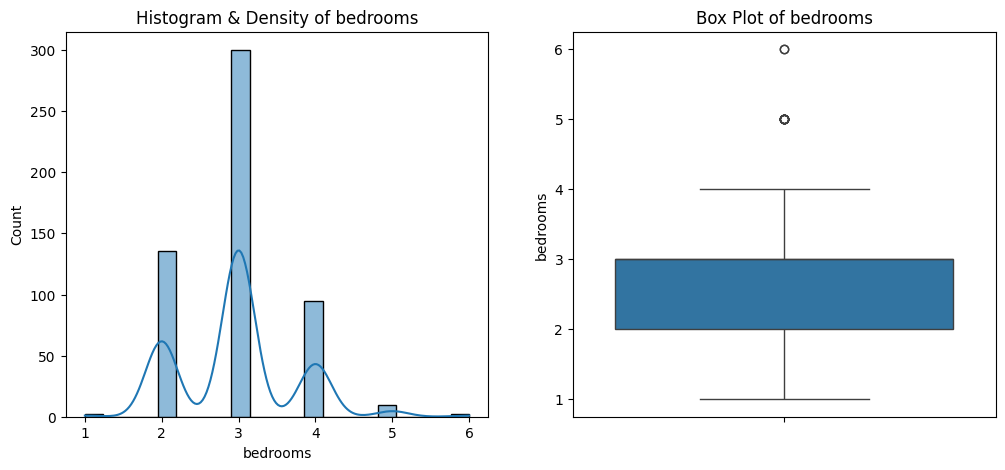

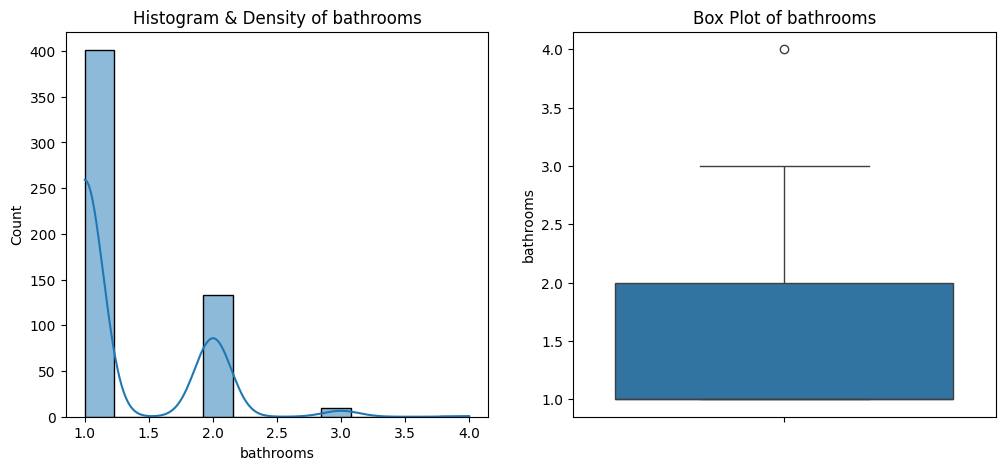

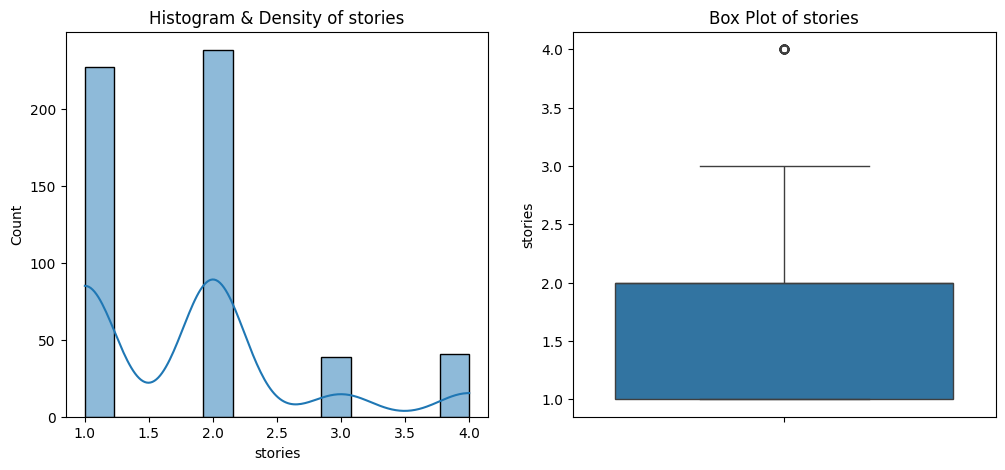

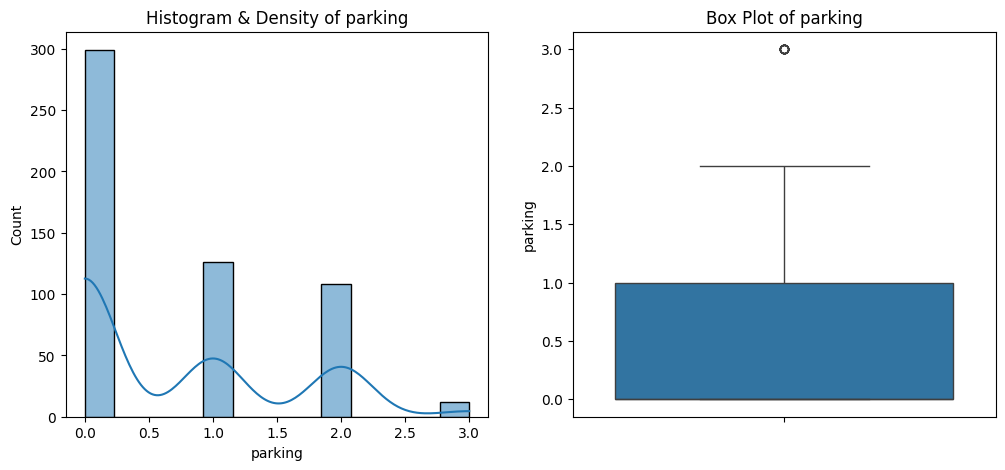

In [12]:
numerical_cols = ['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'parking']

for col in numerical_cols:
    plt.figure(figsize=(12, 5))

    # Histogram + Density
    plt.subplot(1, 2, 1)
    sns.histplot(df[col], kde=True)
    plt.title(f'Histogram & Density of {col}')

    # Box Plot (great for outliers)
    plt.subplot(1, 2, 2)
    sns.boxplot(y=df[col])
    plt.title(f'Box Plot of {col}')

    plt.show()

In [9]:
categorical_cols = ['mainroad', 'guestroom', 'basement', 'hotwaterheating',
                    'airconditioning', 'prefarea', 'furnishingstatus']
print("\nUnique values in categorical columns:")
for col in categorical_cols:
    print(f"{col}: {df[col].unique()}")


Unique values in categorical columns:
mainroad: ['yes' 'no']
guestroom: ['no' 'yes']
basement: ['no' 'yes']
hotwaterheating: ['no' 'yes']
airconditioning: ['yes' 'no']
prefarea: ['yes' 'no']
furnishingstatus: ['furnished' 'semi-furnished' 'unfurnished']


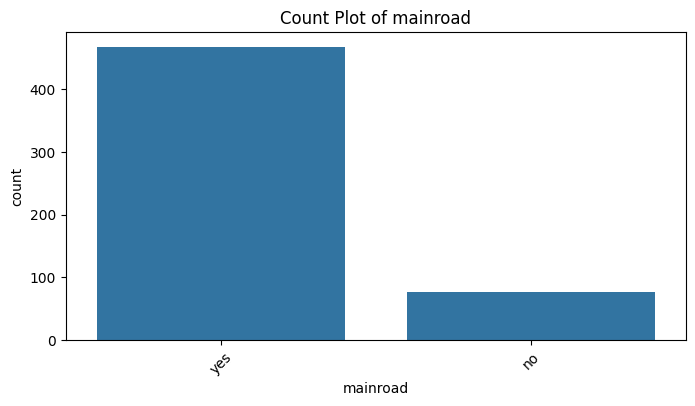

mainroad
yes    85.87156
no     14.12844
Name: proportion, dtype: float64


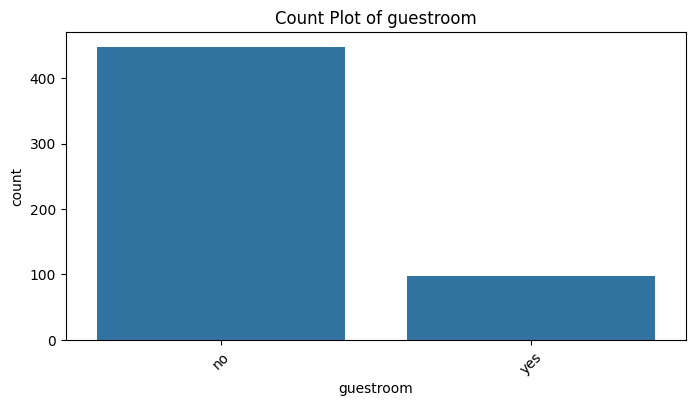

guestroom
no     82.201835
yes    17.798165
Name: proportion, dtype: float64


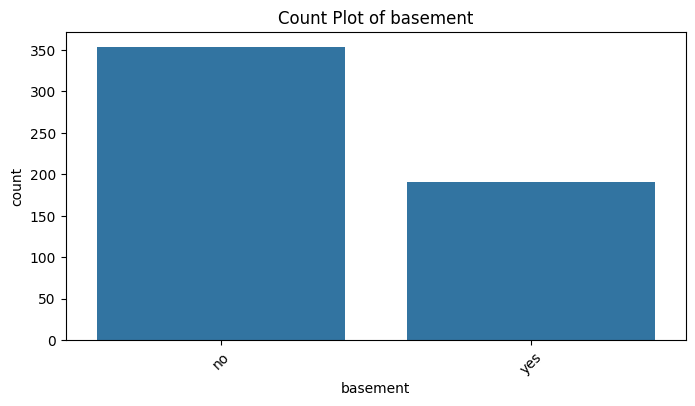

basement
no     64.954128
yes    35.045872
Name: proportion, dtype: float64


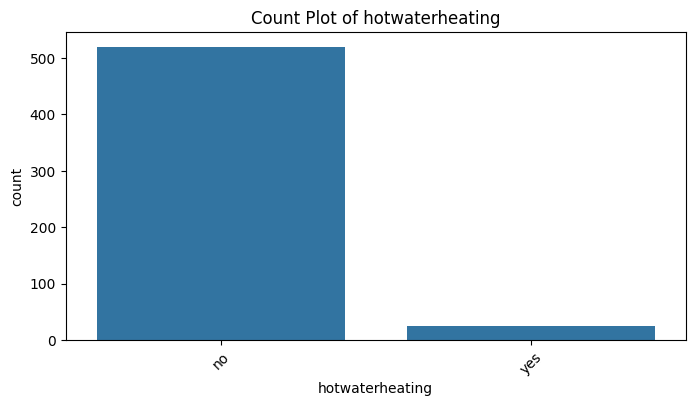

hotwaterheating
no     95.412844
yes     4.587156
Name: proportion, dtype: float64


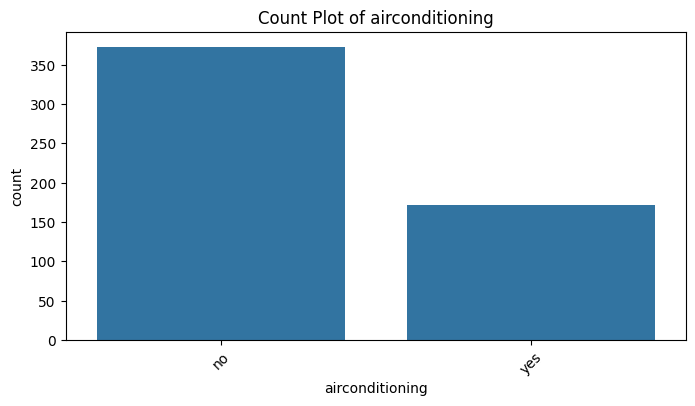

airconditioning
no     68.440367
yes    31.559633
Name: proportion, dtype: float64


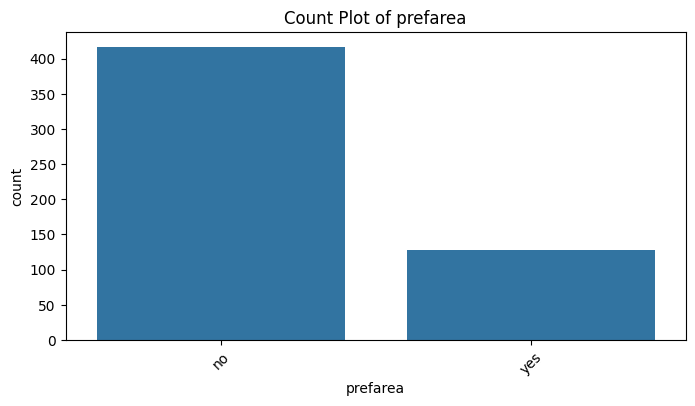

prefarea
no     76.513761
yes    23.486239
Name: proportion, dtype: float64


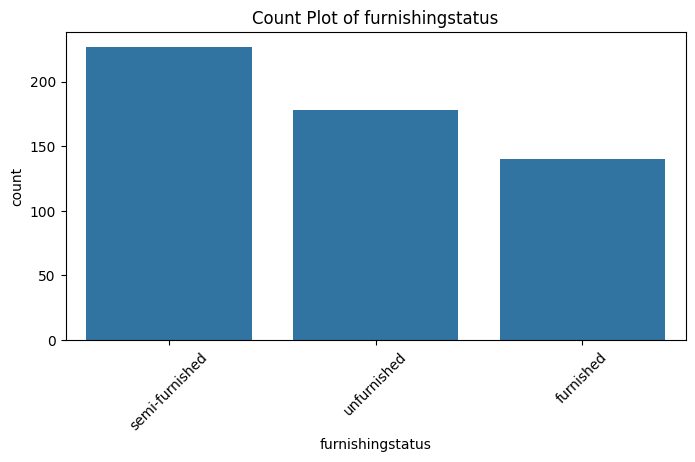

furnishingstatus
semi-furnished    41.651376
unfurnished       32.660550
furnished         25.688073
Name: proportion, dtype: float64


In [8]:
categorical_cols = ['mainroad', 'guestroom', 'basement', 'hotwaterheating',
                    'airconditioning', 'prefarea', 'furnishingstatus']

for col in categorical_cols:
    plt.figure(figsize=(8, 4))
    sns.countplot(data=df, x=col, order=df[col].value_counts().index)
    plt.title(f'Count Plot of {col}')
    plt.xticks(rotation=45)
    plt.show()

    # Percentage
    print(df[col].value_counts(normalize=True) * 100)

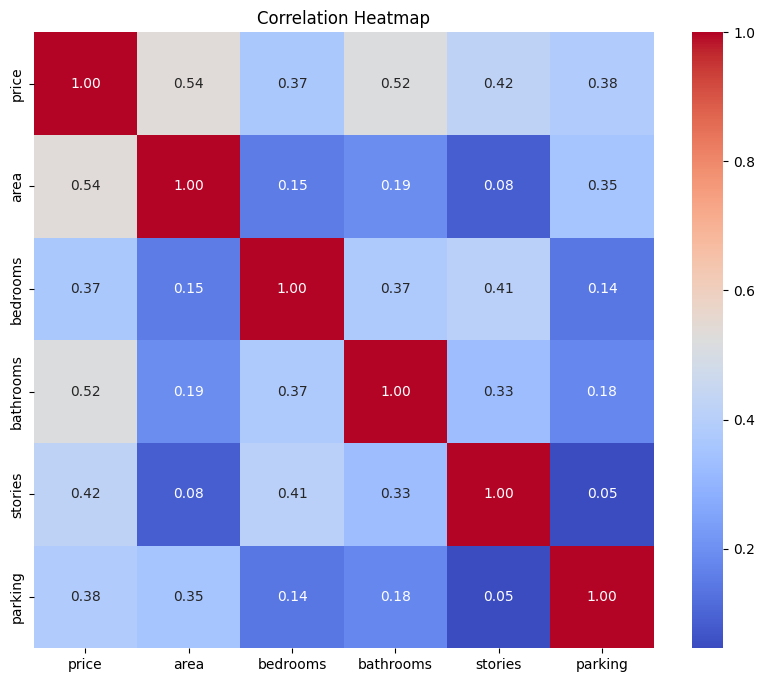

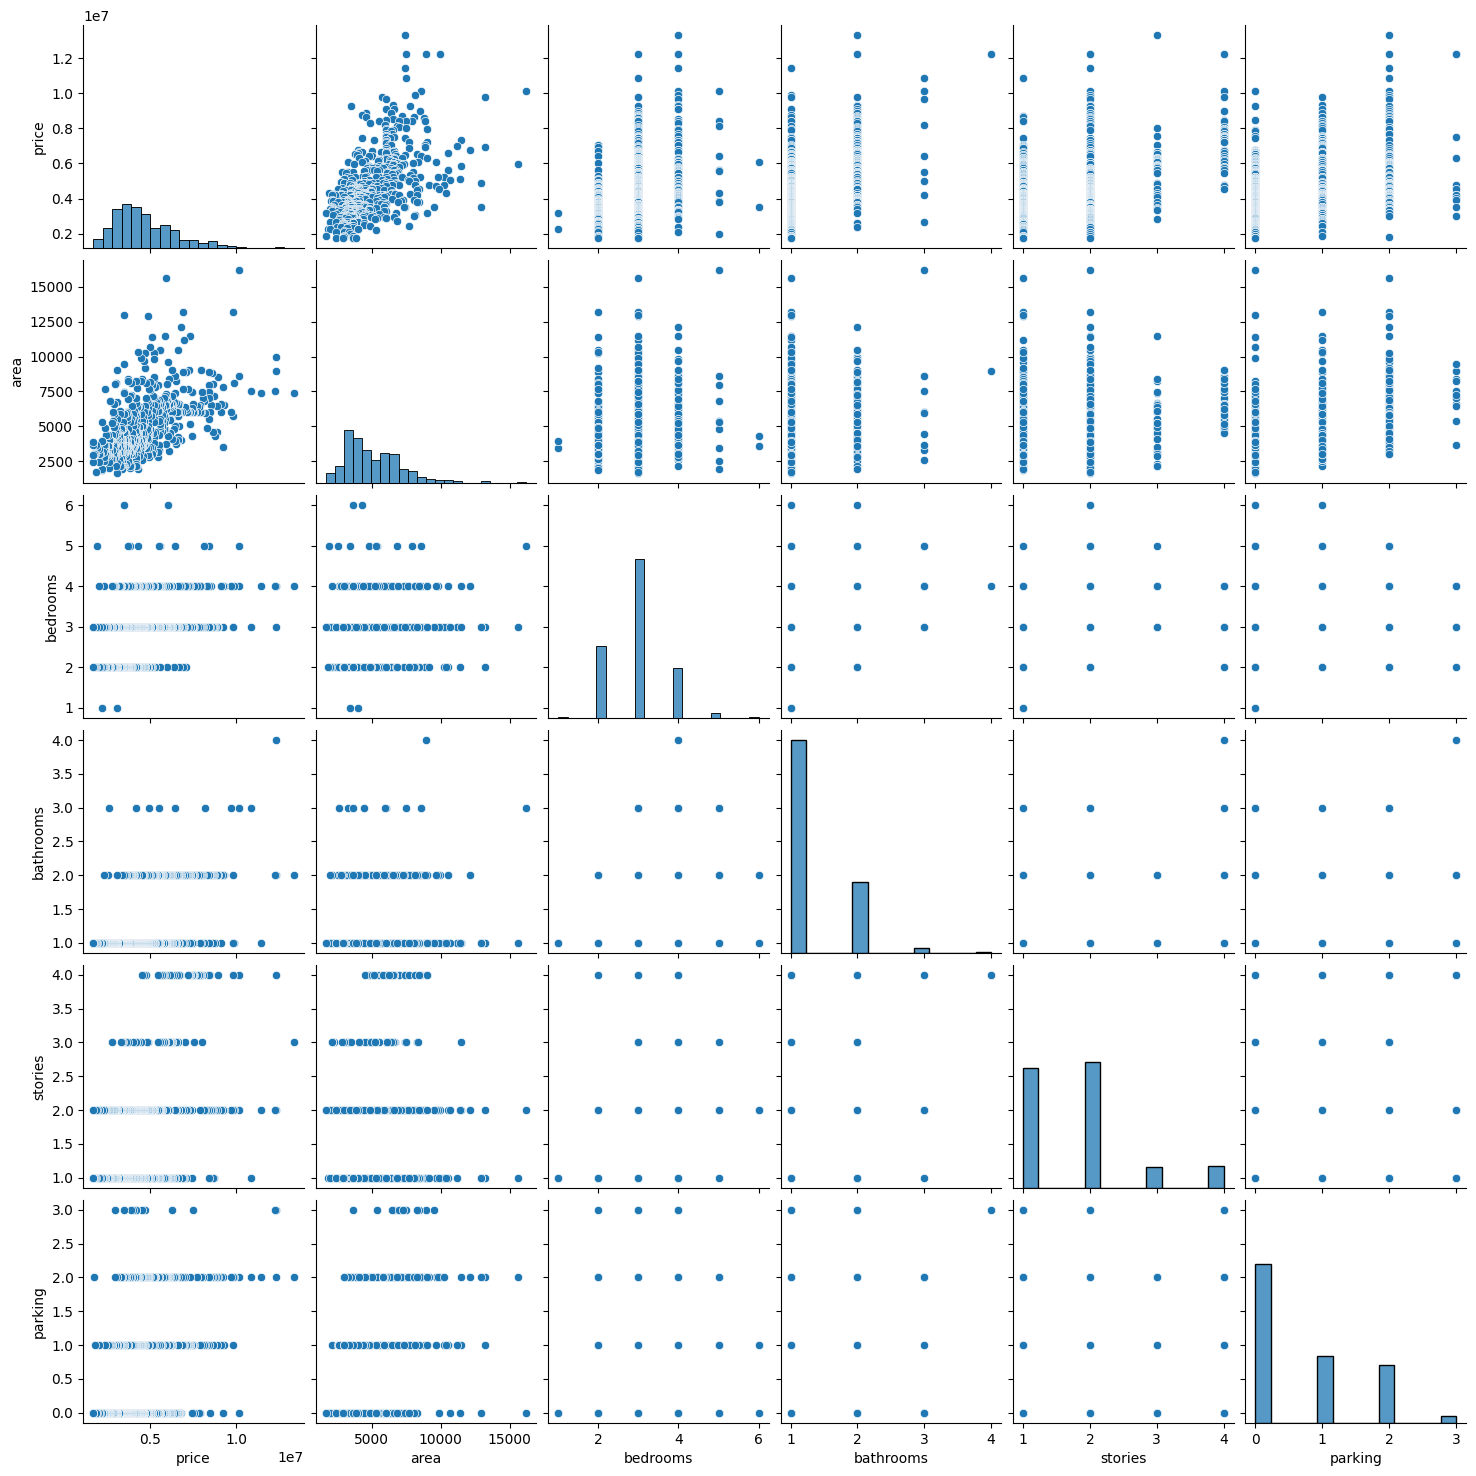

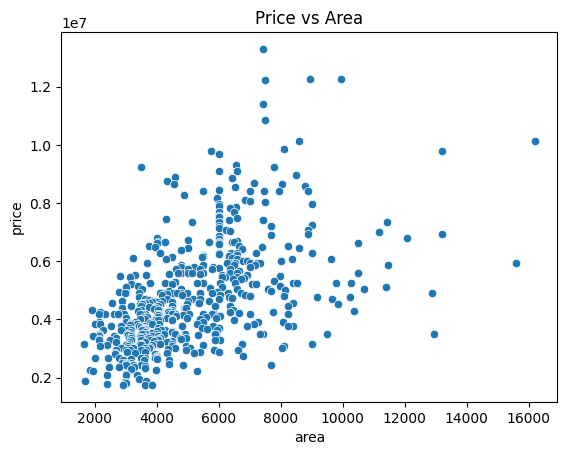

In [13]:
# Correlation Matrix
plt.figure(figsize=(10, 8))
corr = df[numerical_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

# Pair Plot (very useful)
sns.pairplot(df[numerical_cols])
plt.show()

# Scatter plots (example)
sns.scatterplot(data=df, x='area', y='price')
plt.title('Price vs Area')
plt.show()

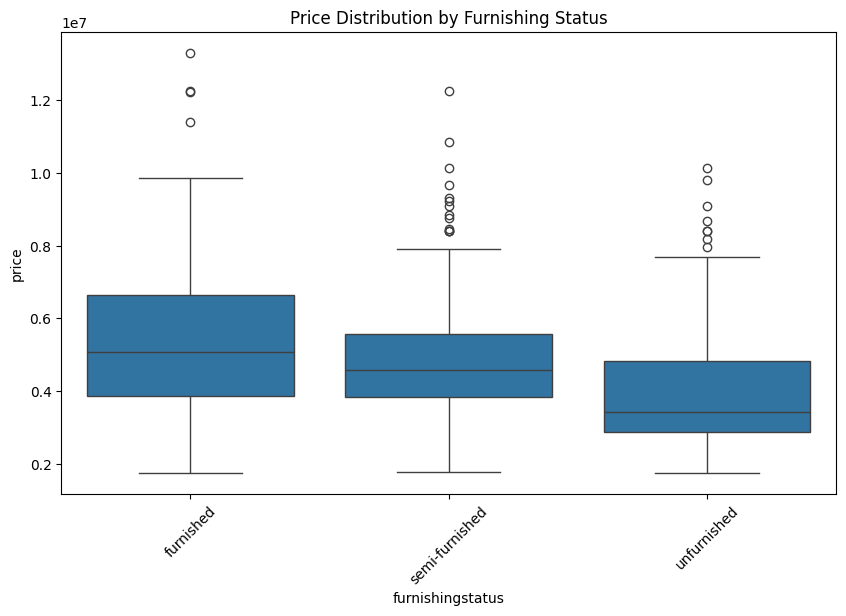

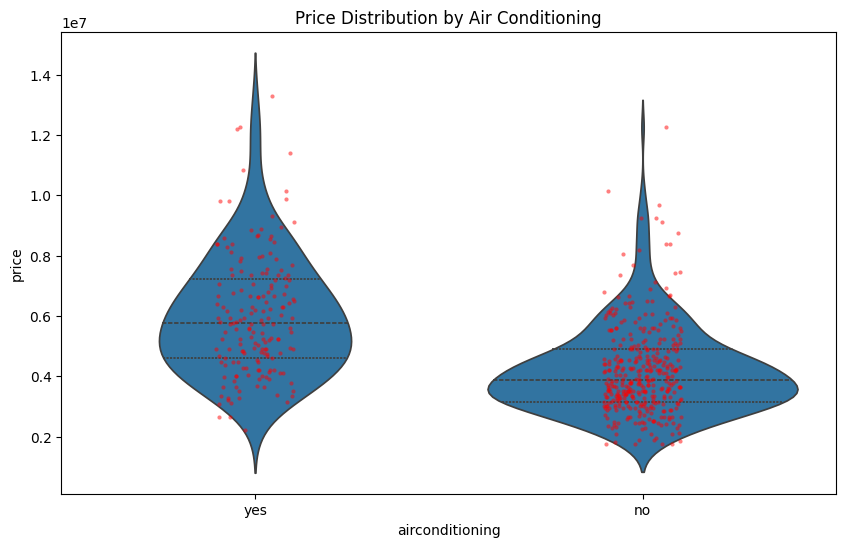

In [15]:
# Price by Furnishing Status
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='furnishingstatus', y='price')
plt.title('Price Distribution by Furnishing Status')
plt.xticks(rotation=45)
plt.show()

# Air Conditioning Analysis
plt.figure(figsize=(10, 6))
sns.violinplot(data=df, x='airconditioning', y='price', inner='quartile')
sns.stripplot(data=df, x='airconditioning', y='price', color='red',
              alpha=0.5, jitter=True, size=3)
plt.title('Price Distribution by Air Conditioning')
plt.show()

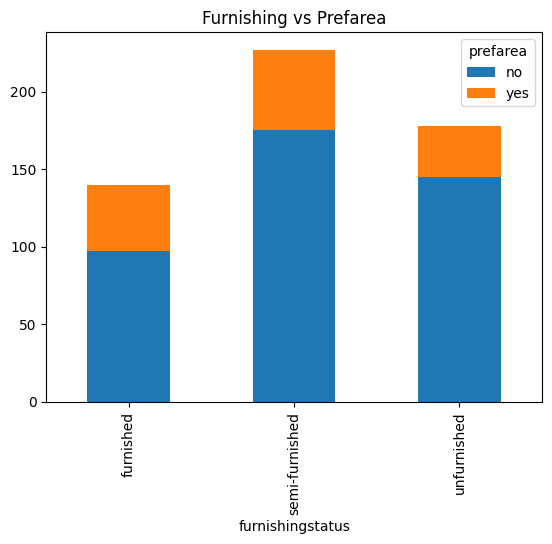

In [16]:
# Crosstab example
pd.crosstab(df['furnishingstatus'], df['airconditioning'], normalize='index')

# Stacked Bar
pd.crosstab(df['furnishingstatus'], df['prefarea']).plot(kind='bar', stacked=True)
plt.title('Furnishing vs Prefarea')
plt.show()

# 5. Data Preprocessing

In [61]:
# Data Preprocessing

num_cols = ['area', 'bedrooms', 'bathrooms', 'stories', 'parking']
binary_cols = ['mainroad', 'guestroom', 'basement', 'hotwaterheating',
               'airconditioning', 'prefarea']
multi_cols = ['furnishingstatus']

# Numerical features
num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Binary: Yes/No → 1/0
def binary_encode(X):
    """Convert yes/no to 1/0 without FutureWarning"""
    X = X.copy()
    # More explicit and clean way
    X = X.replace({'yes': 1, 'no': 0})
    return X.astype('int32')

binary_transformer = FunctionTransformer(binary_encode, validate=False)

# Multi-class: One-Hot Encoding
multi_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(drop='first',
                             sparse_output=False,
                             handle_unknown='ignore'))
])

# Full Preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num',   num_transformer, num_cols),
        ('bin',   binary_transformer, binary_cols),
        ('multi', multi_transformer, multi_cols)
    ],
    remainder='passthrough'
)

print("Preprocessor created successfully")

Preprocessor created successfully


# 6. Feature Selection

In [38]:
#  Feature Selection

# Create a copy to avoid warnings
numeric_df = df[num_cols + ['price']].copy()

# Correlation with target variable
correlation = numeric_df.corr()['price'].sort_values(ascending=False)

print("Correlation with Price:")
print(correlation.round(4))

# Quick insights
print("\n" + "="*25)
print("Top Correlated Features:")
print(correlation[1:6].round(4))  # Top 5 excluding price itself

Correlation with Price:
price        1.0000
area         0.5360
bathrooms    0.5175
stories      0.4207
parking      0.3844
bedrooms     0.3665
Name: price, dtype: float64

Top Correlated Features:
area         0.5360
bathrooms    0.5175
stories      0.4207
parking      0.3844
bedrooms     0.3665
Name: price, dtype: float64


FEATURE SELECTION & VISUALIZATION SUMMARY
Correlation with Price:
price        1.0000
area         0.5360
bathrooms    0.5175
stories      0.4207
parking      0.3844
bedrooms     0.3665
Name: price, dtype: float64

Strongly correlated features (|corr| > 0.3): ['area', 'bathrooms', 'stories', 'parking', 'bedrooms']

Recommended Feature Sets:
   • Best Single Feature : area
   • Top 2 Features      : ['area', 'bathrooms']
   • Top 3 Features      : ['area', 'bathrooms', 'stories']
   • Top 5 Features      : ['area', 'bathrooms', 'stories', 'parking', 'bedrooms']


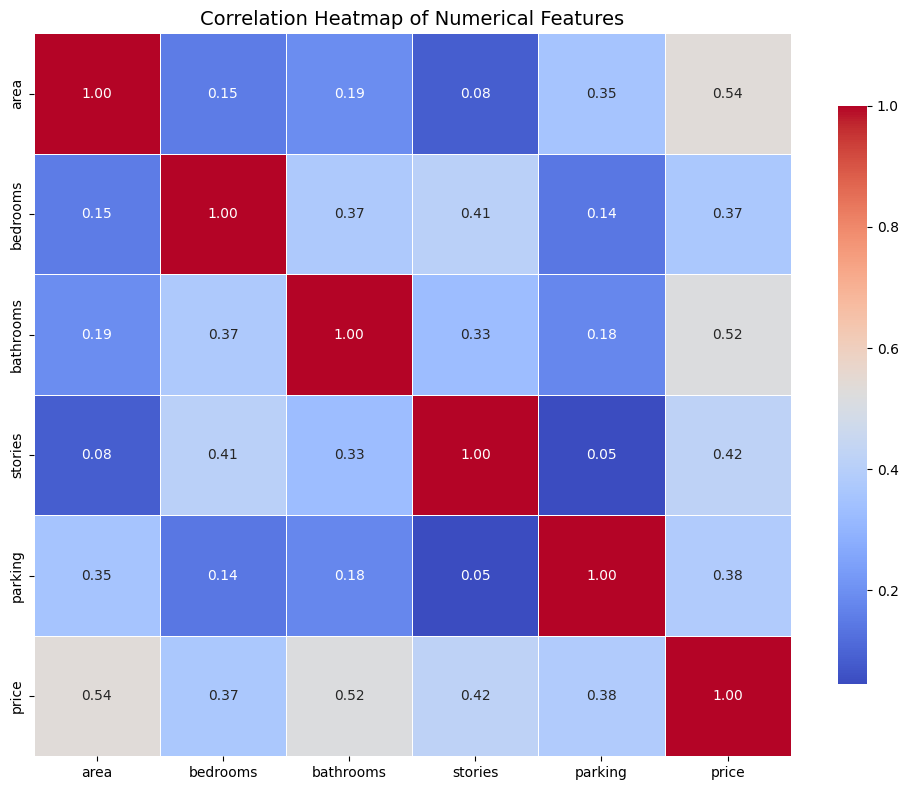

In [39]:
#VISUALIZATION & FEATURE SELECTION

print("FEATURE SELECTION & VISUALIZATION SUMMARY")
print("=" * 40)

# 1. Correlation Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(numeric_df.corr(),
            annot=True,
            cmap='coolwarm',
            fmt='.2f',
            linewidths=0.5,
            cbar_kws={'shrink': 0.8})
plt.title('Correlation Heatmap of Numerical Features', fontsize=14)
plt.tight_layout()


# 2. Correlation with Target
corr_with_price = numeric_df.corr()['price'].sort_values(ascending=False)

print("Correlation with Price:")
print(corr_with_price.round(4))

# 3. Dynamic Feature Selection
threshold = 0.3
strong_features = corr_with_price[abs(corr_with_price) > threshold].index.tolist()
if 'price' in strong_features:
    strong_features.remove('price')

print(f"\nStrongly correlated features (|corr| > {threshold}): {strong_features}")

# 4. Recommended Feature Sets (Dynamic)
print(f"\nRecommended Feature Sets:")
print(f"   • Best Single Feature : {corr_with_price.index[1]}")
print(f"   • Top 2 Features      : {list(corr_with_price.index[1:3])}")
print(f"   • Top 3 Features      : {list(corr_with_price.index[1:4])}")
print(f"   • Top 5 Features      : {list(corr_with_price.index[1:6])}")

In [40]:
best_single_feature = 'area'
best_two_features = ['area', 'bathrooms']
best_three_features = ['area', 'bathrooms', 'stories']

#7. Model Training & Evaluation

In [48]:
import pandas as pd
pd.set_option('future.no_silent_downcasting', True)

X = df.drop('price', axis=1)
y = df['price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training samples: {X_train.shape[0]:,}")
print(f"Testing samples : {X_test.shape[0]:,}\n")

def binary_encode(X):
    X = X.copy()
    return X.replace({'yes': 1, 'no': 0}).astype(int)

binary_transformer = FunctionTransformer(binary_encode, validate=False)

# Rebuild Preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num',   num_transformer, num_cols),
        ('bin',   binary_transformer, binary_cols),
        ('multi', multi_transformer, multi_cols)
    ],
    remainder='passthrough'
)

# Evaluation Function
def evaluate_model(model, X_train, X_test, y_train, y_test, model_name):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    print(f"{model_name}")
    print("-" * 50)
    print(f"RMSE : {rmse:,.2f}")
    print(f"MAE  : {mae:,.2f}")
    print(f"R²   : {r2:.4f}\n")
    return rmse, mae, r2

# Models

model_uni = Pipeline([
    ('preprocessor', ColumnTransformer([('num', StandardScaler(), [best_single_feature])])),
    ('regressor', LinearRegression())
])
rmse_uni, mae_uni, r2_uni = evaluate_model(model_uni, X_train[[best_single_feature]], X_test[[best_single_feature]],
               y_train, y_test, "Model 1: Univariate (Only Area)")

model_bi = Pipeline([
    ('preprocessor', ColumnTransformer([('num', StandardScaler(), best_two_features)])),
    ('regressor', LinearRegression())
])
rmse_bi, mae_bi, r2_bi = evaluate_model(model_bi, X_train[best_two_features], X_test[best_two_features],
               y_train, y_test, f"Model 2: Bivariate ({best_two_features})")

model_multi = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])
rmse_multi, mae_multi, r2_multi = evaluate_model(model_multi, X_train, X_test, y_train, y_test,
               "Model 3: Full Multivariate (All Features)")

# Fixed Cross Validation
cv_scores = cross_val_score(model_multi, X_train, y_train, cv=5, scoring='r2')   # Use X_train only!
print(f"5-Fold Cross Validation R²: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

Training samples: 436
Testing samples : 109

Model 1: Univariate (Only Area)
--------------------------------------------------
RMSE : 1,917,103.70
MAE  : 1,474,748.13
R²   : 0.2729

Model 2: Bivariate (['area', 'bathrooms'])
--------------------------------------------------
RMSE : 1,698,621.06
MAE  : 1,295,658.15
R²   : 0.4292

Model 3: Full Multivariate (All Features)
--------------------------------------------------
RMSE : 1,324,506.96
MAE  : 970,043.40
R²   : 0.6529

5-Fold Cross Validation R²: 0.6470 ± 0.0367


## 7.1 Performance Comparison

Model 1: Univariate (Only Area)
--------------------------------------------------
RMSE : 1,917,103.70
MAE  : 1,474,748.13
R²   : 0.2729

Model 2: Bivariate (['area', 'bathrooms'])
--------------------------------------------------
RMSE : 1,698,621.06
MAE  : 1,295,658.15
R²   : 0.4292

Model 3: Full Multivariate (All Features)
--------------------------------------------------
RMSE : 1,324,506.96
MAE  : 970,043.40
R²   : 0.6529


MODEL PERFORMANCE COMPARISON
                        Model       RMSE        MAE   R²
      Univariate\n(Only Area) 1917103.70 1474748.13 0.27
Bivariate\n(Area + Bathrooms) 1698621.06 1295658.15 0.43
 Multivariate\n(All Features) 1324506.96  970043.40 0.65


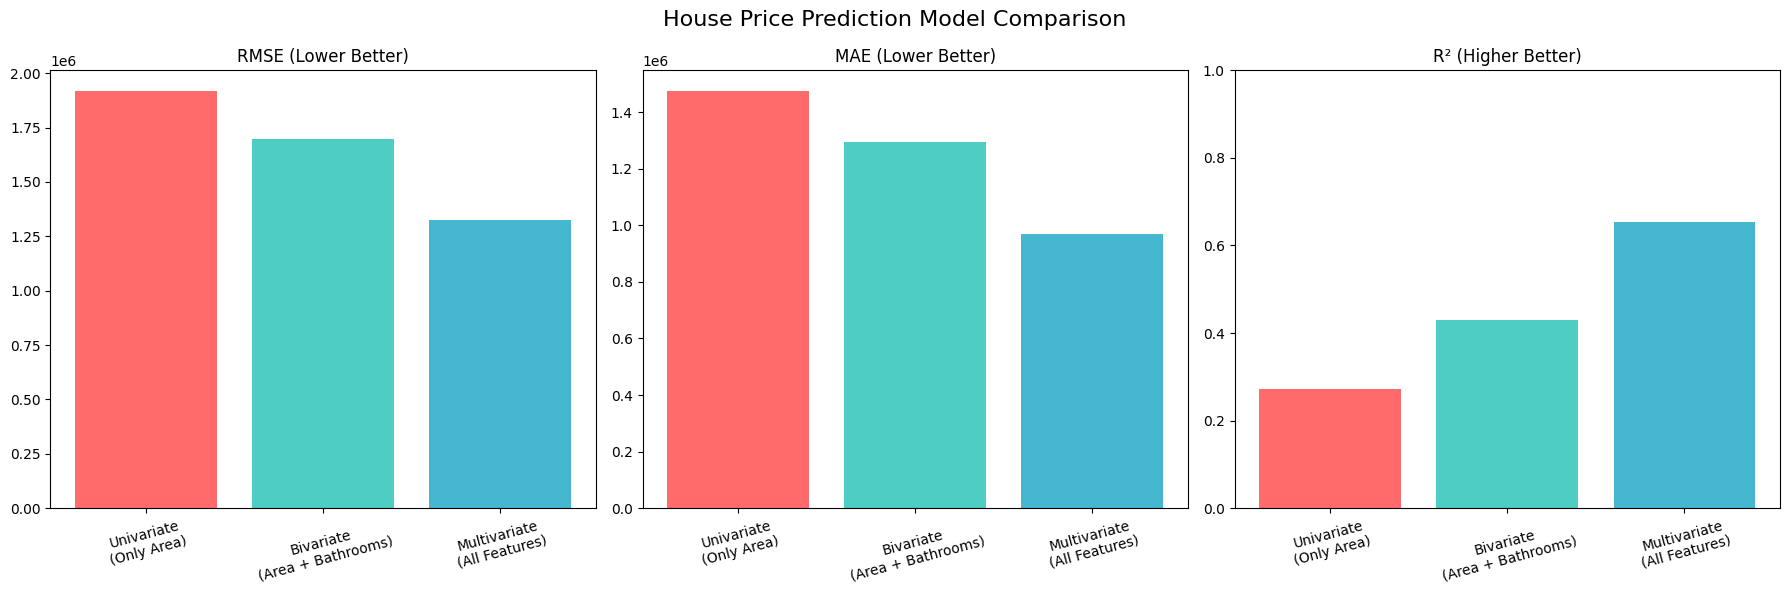

In [52]:
# Performance Comparison

rmse_uni, mae_uni, r2_uni = evaluate_model(model_uni,
                                           X_train[[best_single_feature]],
                                           X_test[[best_single_feature]],
                                           y_train, y_test,
                                           "Model 1: Univariate (Only Area)")

rmse_bi, mae_bi, r2_bi = evaluate_model(model_bi,
                                        X_train[best_two_features],
                                        X_test[best_two_features],
                                        y_train, y_test,
                                        f"Model 2: Bivariate ({best_two_features})")

rmse_multi, mae_multi, r2_multi = evaluate_model(model_multi,
                                                 X_train, X_test,
                                                 y_train, y_test,
                                                 "Model 3: Full Multivariate (All Features)")

# Create Comparison Table
comparison_df = pd.DataFrame({
    'Model': [
        'Univariate\n(Only Area)',
        'Bivariate\n(Area + Bathrooms)',
        'Multivariate\n(All Features)'
    ],
    'RMSE': [rmse_uni, rmse_bi, rmse_multi],
    'MAE':  [mae_uni, mae_bi, mae_multi],
    'R²':   [r2_uni, r2_bi, r2_multi]
})

print("\n" + "="*55)
print("MODEL PERFORMANCE COMPARISON")
print("="*55)
print(comparison_df.round(2).to_string(index=False))

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']

for ax, metric, title in zip(axes, ['RMSE', 'MAE', 'R²'],
                           ['RMSE (Lower Better)', 'MAE (Lower Better)', 'R² (Higher Better)']):
    ax.bar(comparison_df['Model'], comparison_df[metric], color=colors)
    ax.set_title(title)
    ax.tick_params(axis='x', rotation=15)
    if metric == 'R²':
        ax.set_ylim(0, 1)

plt.suptitle('House Price Prediction Model Comparison', fontsize=16)
plt.tight_layout()


## 7.2  Model Interpretation

In [55]:
# Model Interpretation

print("\n" + "="*70)
print(" MODEL INTERPRETATION (Linear Regression Coefficients)")
print("="*70)

# Get feature names manually
num_features = num_cols
bin_features = binary_cols
multi_features = list(model_multi.named_steps['preprocessor']
                      .named_transformers_['multi']
                      .named_steps['onehot']
                      .get_feature_names_out(multi_cols))

feature_names = num_features + bin_features + multi_features

# Extract coefficients
coef = model_multi.named_steps['regressor'].coef_
intercept = model_multi.named_steps['regressor'].intercept_

coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coef
}).sort_values(by='Coefficient', ascending=False)

print(coef_df.round(3).to_string(index=False))
print(f"\nIntercept: {intercept:,.2f}")

# Show Top 5 Positive and Negative
print("\nTop 5 Most Positive Features:")
print(coef_df.head(5)[['Feature', 'Coefficient']].round(3).to_string(index=False))

print("\nTop 5 Most Negative Features:")
print(coef_df.tail(5)[['Feature', 'Coefficient']].round(3).to_string(index=False))


STEP 6: MODEL INTERPRETATION (Linear Regression Coefficients)
                        Feature  Coefficient
                airconditioning   791426.736
                hotwaterheating   684649.885
                       prefarea   629890.565
                      bathrooms   521879.028
                           area   519552.416
                       basement   390251.176
                       mainroad   367919.948
                        stories   349251.439
                      guestroom   231610.037
                        parking   192005.954
                       bedrooms    57349.559
furnishingstatus_semi-furnished  -126881.818
   furnishingstatus_unfurnished  -413645.062

Intercept: 3,969,403.56

Top 5 Most Positive Features:
        Feature  Coefficient
airconditioning   791426.736
hotwaterheating   684649.885
       prefarea   629890.565
      bathrooms   521879.028
           area   519552.416

Top 5 Most Negative Features:
                        Feature  Coefficient
 

Visualizing Linear Regression Training Process 


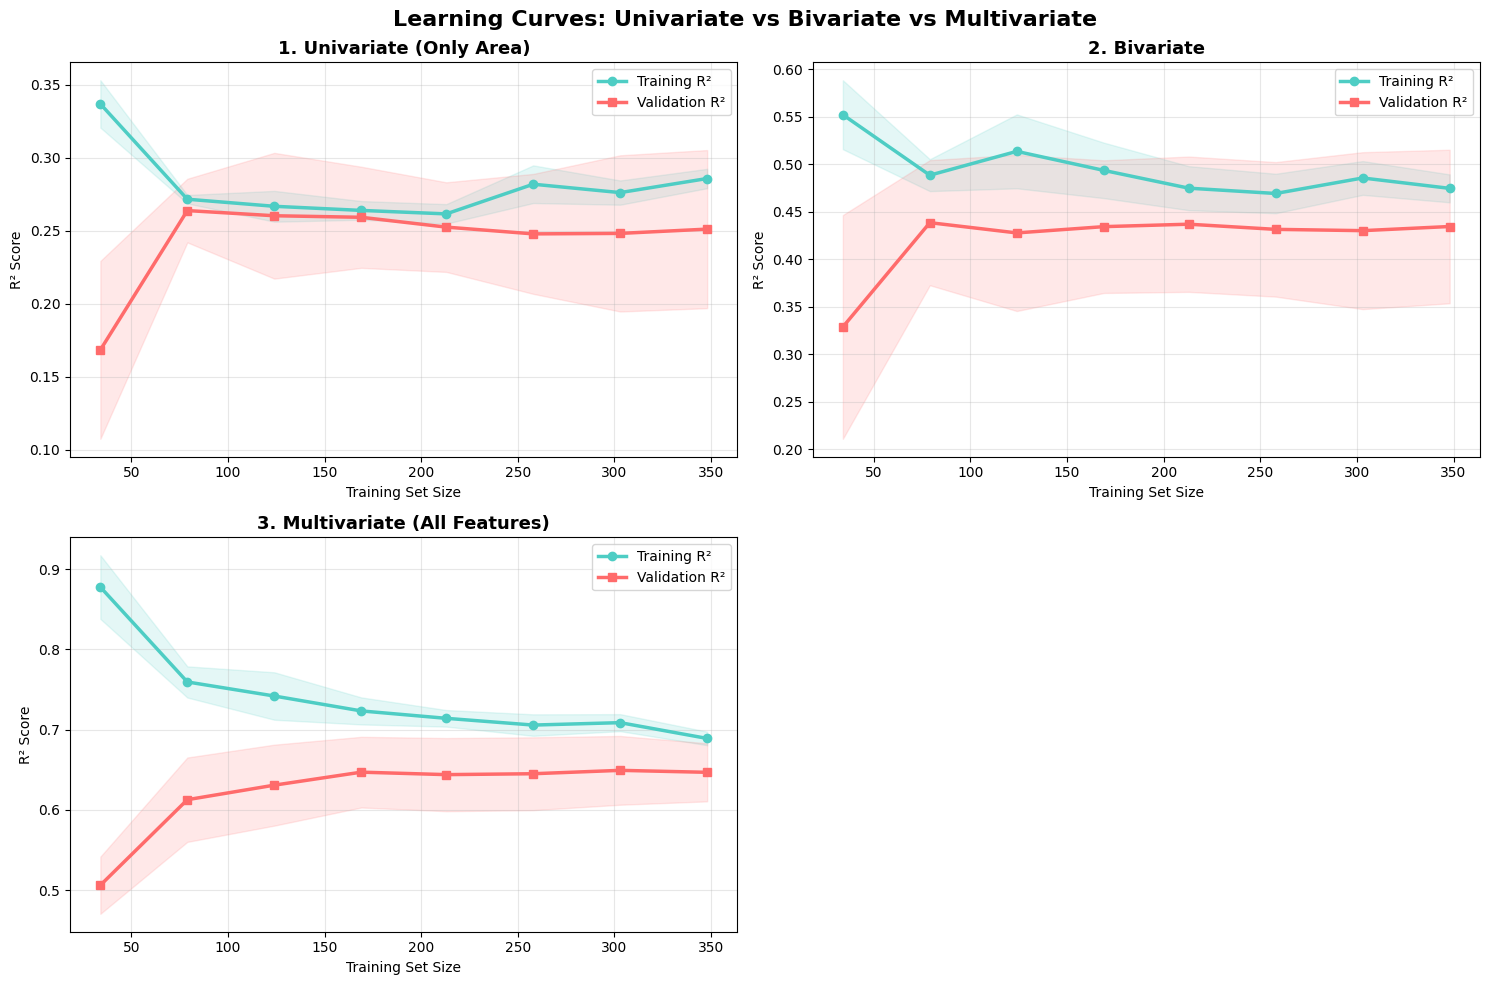


FINAL PERFORMANCE COMPARISON
1. Univariate (Only Area)
--------------------------------------------------
RMSE : 1,917,103.70
MAE  : 1,474,748.13
R²   : 0.2729

2. Bivariate
--------------------------------------------------
RMSE : 1,698,621.06
MAE  : 1,295,658.15
R²   : 0.4292

3. Multivariate (All Features)
--------------------------------------------------
RMSE : 1,324,506.96
MAE  : 970,043.40
R²   : 0.6529



In [70]:
print("Visualizing Linear Regression Training Process ")

# Define the three models (already created earlier)
models_dict = {
    "1. Univariate (Only Area)": (model_uni, X_train[[best_single_feature]], X_test[[best_single_feature]]),
    "2. Bivariate": (model_bi, X_train[best_two_features], X_test[best_two_features]),
    "3. Multivariate (All Features)": (model_multi, X_train, X_test)
}

plt.figure(figsize=(15, 10))

for i, (name, (model, X_tr, X_te)) in enumerate(models_dict.items(), 1):


    # Learning Curve
    train_sizes, train_scores, test_scores = learning_curve(
        model, X_tr, y_train,
        train_sizes=np.linspace(0.1, 1.0, 8),
        cv=5, scoring='r2', n_jobs=-1
    )

    train_mean = np.mean(train_scores, axis=1)
    train_std = np.std(train_scores, axis=1)
    test_mean = np.mean(test_scores, axis=1)
    test_std = np.std(test_scores, axis=1)

    plt.subplot(2, 2, i)
    plt.plot(train_sizes, train_mean, 'o-', color='#4ECDC4', linewidth=2.5, label='Training R²')
    plt.plot(train_sizes, test_mean, 's-', color='#FF6B6B', linewidth=2.5, label='Validation R²')

    plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15, color='#4ECDC4')
    plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.15, color='#FF6B6B')

    plt.title(name, fontsize=13, fontweight='bold')
    plt.xlabel('Training Set Size')
    plt.ylabel('R² Score')
    plt.legend(loc='best')
    plt.grid(True, alpha=0.3)

plt.suptitle('Learning Curves: Univariate vs Bivariate vs Multivariate',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# ====================== FINAL EVALUATION ======================
print("\n" + "="*60)
print("FINAL PERFORMANCE COMPARISON")
print("="*60)

for name, (model, X_tr, X_te) in models_dict.items():
    model.fit(X_tr, y_train)
    y_pred = model.predict(X_te)

    print(f"{name}")
    print("-" * 50)
    print(f"RMSE : {np.sqrt(mean_squared_error(y_test, y_pred)):,.2f}")
    print(f"MAE  : {mean_absolute_error(y_test, y_pred):,.2f}")
    print(f"R²   : {r2_score(y_test, y_pred):.4f}\n")

## 7.3  Prediction on New House

In [57]:
#  Prediction on New House
print("PREDICTION ON A NEW HOUSE")
new_house = pd.DataFrame([{
    'area': 8500,
    'bedrooms': 4,
    'bathrooms': 2,
    'stories': 3,
    'mainroad': 'yes',
    'guestroom': 'no',
    'basement': 'yes',
    'hotwaterheating': 'no',
    'airconditioning': 'yes',
    'parking': 2,
    'prefarea': 'yes',
    'furnishingstatus': 'furnished'
}])

# Make predictions
pred_uni = model_uni.predict(new_house[[best_single_feature]])[0]
pred_bi = model_bi.predict(new_house[best_two_features])[0]
pred_multi = model_multi.predict(new_house)[0]

print("New House Details:")
for key, value in new_house.iloc[0].items():
    print(f"   {key:20} : {value}")

print("\nPredicted Prices:")
print(f"   Univariate Model    : {pred_uni:,.2f}")
print(f"   Bivariate Model     : {pred_bi:,.2f}")
print(f"   Multivariate Model  : {pred_multi:,.2f}")

PREDICTION ON A NEW HOUSE
New House Details:
   area                 : 8500
   bedrooms             : 4
   bathrooms            : 2
   stories              : 3
   mainroad             : yes
   guestroom            : no
   basement             : yes
   hotwaterheating      : no
   airconditioning      : yes
   parking              : 2
   prefarea             : yes
   furnishingstatus     : furnished

Predicted Prices:
   Univariate Model    : 6,130,957.92
   Bivariate Model     : 7,094,479.97
   Multivariate Model  : 8,613,373.61


# 8. Model Deployment Preparation

In [103]:
print("="*60)
print("MODEL DEPLOYMENT PREPARATION - LINEAR REGRESSION")
print("="*60)

# Select best model
best_model = model_multi
best_model_name = "Multivariate (All Features)"

print(f"Selected model for deployment: {best_model_name}")

# Final performance
best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"RMSE : {rmse:,.2f}")
print(f"MAE  : {mae:,.2f}")
print(f"R²   : {r2:.4f}")

# ====================== PREDICTION FUNCTION ======================
def predict_house_price(input_data):
    """Predict house price"""
    if isinstance(input_data, dict):
        df_input = pd.DataFrame([input_data])
    else:
        df_input = pd.DataFrame([input_data], columns=X.columns)

    predicted_price = best_model.predict(df_input)[0]

    return {
        'predicted_price': round(predicted_price, 2),
        'formatted_price': f"${predicted_price:,.2f}",
        'r2_score': round(r2, 4)
    }

# Test
print("\nTesting prediction function...")
sample = {
    'area': 7420, 'bedrooms': 4, 'bathrooms': 2, 'stories': 3,
    'mainroad': 'yes', 'guestroom': 'no', 'basement': 'no',
    'hotwaterheating': 'no', 'airconditioning': 'yes',
    'parking': 2, 'prefarea': 'yes', 'furnishingstatus': 'furnished'
}

result = predict_house_price(sample)
print(f"Predicted Price: {result['formatted_price']}")

# ====================== SAVE MODEL (Fixed) ======================
import joblib
import os
import cloudpickle   # Better for custom functions

os.makedirs('models', exist_ok=True)

# Use cloudpickle to handle FunctionTransformer properly
with open('models/house_price_model.pkl', 'wb') as f:
    cloudpickle.dump(best_model, f)

print("\nModel saved successfully!")
print("   - Model saved at: models/house_price_model.pkl")

MODEL DEPLOYMENT PREPARATION - LINEAR REGRESSION
Selected model for deployment: Multivariate (All Features)
RMSE : 1,324,506.96
MAE  : 970,043.40
R²   : 0.6529

Testing prediction function...
Predicted Price: $7,968,276.13

Model saved successfully!
   - Model saved at: models/house_price_model.pkl


# 9. Streamlit Deployment Application or Using Flask
#### This is a streamlit application.
#### This notebook saves the app as a python file in the project directory.

## 9.1 Install Streamlit

In [102]:
!pip install streamlit -qq

In [101]:
streamlit_code = '''
import streamlit as st
import pandas as pd
import cloudpickle

st.set_page_config(page_title="House Price Predictor", layout="centered")

# Load Model
@st.cache_resource
def load_model():
    with open("models/house_price_model.pkl", "rb") as f:
        return cloudpickle.load(f)

model = load_model()

st.title("Modern House Price Predictor")
st.markdown("### Get instant price prediction for your dream house")

# Modern Input Form
with st.container():
    col1, col2 = st.columns(2)

    with col1:
        st.subheader("Basic Details")
        area = st.number_input("Area (sq ft)", 500, 20000, 7420, step=50)
        bedrooms = st.select_slider("Bedrooms", options=[1,2,3,4,5,6], value=4)
        bathrooms = st.select_slider("Bathrooms", options=[1,2,3,4,5], value=2)
        stories = st.select_slider("Stories", options=[1,2,3,4], value=3)
        parking = st.select_slider("Parking Spaces", options=[0,1,2,3,4], value=2)

    with col2:
        st.subheader("Amenities")
        mainroad = st.radio("Main Road Access", ["Yes", "No"], horizontal=True)
        guestroom = st.radio("Guest Room", ["Yes", "No"], horizontal=True)
        basement = st.radio("Basement", ["Yes", "No"], horizontal=True)
        hotwater = st.radio("Hot Water Heating", ["Yes", "No"], horizontal=True)
        aircon = st.radio("Air Conditioning", ["Yes", "No"], horizontal=True, index=1)
        prefarea = st.radio("Preferred Area", ["Yes", "No"], horizontal=True, index=1)
        furnishing = st.selectbox("Furnishing Status",
                                ["furnished", "semi-furnished", "unfurnished"],
                                index=0)

# Convert Yes/No to lowercase for model
input_data = {
    'area': [area],
    'bedrooms': [bedrooms],
    'bathrooms': [bathrooms],
    'stories': [stories],
    'mainroad': [mainroad.lower()],
    'guestroom': [guestroom.lower()],
    'basement': [basement.lower()],
    'hotwaterheating': [hotwater.lower()],
    'airconditioning': [aircon.lower()],
    'parking': [parking],
    'prefarea': [prefarea.lower()],
    'furnishingstatus': [furnishing]
}

input_df = pd.DataFrame(input_data)

# Predict Button
if st.button("Predict Price", type="primary", use_container_width=True):
    price = model.predict(input_df)[0]

    st.success(f"**Estimated Market Price: ${price:,.2f}**", icon="🏠")

    st.balloons()

    col_a, col_b = st.columns(2)
    with col_a:
        st.metric("Predicted Price", f"${price:,.0f}")
    with col_b:
        st.metric("Size", f"{area:,} sq ft")

    st.subheader("Your House Configuration")
    st.dataframe(input_df.T.rename(columns={0: "Value"}), use_container_width=True)

st.caption("Linear Regression Model | Built with using Streamlit")
'''

with open('house_price_app.py', 'w', encoding='utf-8') as f:
    f.write(streamlit_code)

print("Modern House Price App saved successfully!")

Modern House Price App saved successfully!


In [91]:
!streamlit run house_price_app.py



2026-06-28 11:37:22.828 Uvicorn server started on 0.0.0.0:8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.22.39.139:8501

  Stopping...


In [88]:
import webbrowser
webbrowser.open('http://34.22.39.139:8502')

False

##9.2  Setup & Installation gradio

In [92]:
!pip install gradio cloudpickle -q

In [98]:
import gradio as gr
import pandas as pd
import cloudpickle

# Load model
try:
    with open('models/house_price_model.pkl', 'rb') as f:
        model = cloudpickle.load(f)
except FileNotFoundError:
    model = None
    print("Model file not found!")

def predict_price(area, bedrooms, bathrooms, stories, parking,
                 mainroad, guestroom, basement, hotwater, aircon,
                 prefarea, furnishing):

    if model is None:
        return "Model file not found. Please check the path."

    input_data = {
        'area': [area],
        'bedrooms': [bedrooms],
        'bathrooms': [bathrooms],
        'stories': [stories],
        'mainroad': [mainroad],
        'guestroom': [guestroom],
        'basement': [basement],
        'hotwaterheating': [hotwater],
        'airconditioning': [aircon],
        'parking': [parking],
        'prefarea': [prefarea],
        'furnishingstatus': [furnishing]
    }

    df = pd.DataFrame(input_data)
    try:
        price = model.predict(df)[0]
        return f"${price:,.2f}"
    except Exception as e:
        return f"Error: {str(e)}"


# ==================== Gradio UI ====================
with gr.Blocks(title="House Price Predictor") as demo:
    gr.Markdown("# House Price Predictor")
    gr.Markdown("### Predict house prices based on key features")

    with gr.Row():
        with gr.Column(scale=1):
            area = gr.Number(label="Area (sq ft)", value=7420, minimum=1000)
            bedrooms = gr.Slider(1, 8, value=4, step=1, label="Bedrooms")
            bathrooms = gr.Slider(1, 7, value=2, step=1, label="Bathrooms")
            stories = gr.Slider(1, 6, value=3, step=1, label="Stories")
            parking = gr.Slider(0, 7, value=2, step=1, label="Parking Spaces")

        with gr.Column(scale=1):
            mainroad = gr.Radio(["yes", "no"], label="Main Road Access", value="yes")
            guestroom = gr.Radio(["yes", "no"], label="Guest Room", value="no")
            basement = gr.Radio(["yes", "no"], label="Basement", value="no")
            hotwater = gr.Radio(["yes", "no"], label="Hot Water Heating", value="no")
            aircon = gr.Radio(["yes", "no"], label="Air Conditioning", value="yes")
            prefarea = gr.Radio(["yes", "no"], label="Preferred Area", value="yes")
            furnishing = gr.Dropdown(
                ["furnished", "semi-furnished", "unfurnished"],
                label="Furnishing Status",
                value="furnished"
            )

    predict_btn = gr.Button("Predict Price", variant="primary", size="large")
    output = gr.Textbox(label="Predicted House Price", placeholder="Price will appear here...")

    predict_btn.click(
        predict_price,
        inputs=[area, bedrooms, bathrooms, stories, parking,
                mainroad, guestroom, basement, hotwater, aircon,
                prefarea, furnishing],
        outputs=output
    )

# Launch (compatible with older Gradio versions)
demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://38cf0f0268f2eda3d8.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
